In [51]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Load the Student Performance Data Set
Count the Number of Rows = 25000, Remove Duplicates, Check for Empty Cells - there are none


In [52]:
# Importing necessary libraries
import pandas as pd
file_path = '/content/drive/MyDrive/Colab Notebooks/DataScience102_Project/Student_Performance.csv'
# Load the dataset
data = pd.read_csv(file_path)

# Count the total number of rows in the dataset
total_rows = data.shape[0]

print(f'Total number of rows: {total_rows}\n\n')

#remove duplicate rows
data = data.drop_duplicates()
print('The total number of rows after removing duplicate rows is ', data.shape[0])



Total number of rows: 25000


The total number of rows after removing duplicate rows is  15000


##Split data into Training and Test Data

In [53]:
from sklearn.model_selection import train_test_split

# Assuming 'overall_score' is the target variable
X = data.drop('overall_score', axis=1)
y = data['overall_score']

# Split the data into training and testing sets (80% for training)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

print('First 5 rows of X_train:')
display(X_train.head())

print('\nFirst 5 rows of y_train:')
display(y_train.head())


Shape of X_train: (12000, 15)
Shape of X_test: (3000, 15)
Shape of y_train: (12000,)
Shape of y_test: (3000,)
First 5 rows of X_train:


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,final_grade
9839,9840,16,male,private,high school,1.6,73.5,yes,<15 min,no,online videos,59.1,57.7,53.0,e
9680,9681,14,other,public,diploma,7.6,89.6,yes,<15 min,no,mixed,100.0,86.5,100.0,a
7093,7094,16,other,public,no formal,0.8,60.6,yes,>60 min,no,mixed,20.9,39.8,41.2,f
11293,11294,17,other,private,graduate,6.2,63.3,yes,30-60 min,no,notes,64.2,68.1,71.4,d
820,821,14,other,public,no formal,7.5,89.9,yes,>60 min,yes,group study,91.5,88.9,89.1,a



First 5 rows of y_train:


,overall_score
9839,44.2
9680,100.0
7093,25.0
11293,66.9
820,100.0


## Compute a Correlation and Fit a Regression Line

###study_hours versus overall_score

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Reshape the explanatory variable for sklearn's LinearRegression from training data
X_train_reg = X_train['study_hours'].values.reshape(-1, 1)
y_train_reg = y_train.values

# Create and fit the model on the training data
model_study_hours = LinearRegression()
model_study_hours.fit(X_train_reg, y_train_reg)

# Get the intercept and coefficient
intercept_study_hours = model_study_hours.intercept_
coefficient_study_hours = model_study_hours.coef_[0]

print(f"Regression Line on Training Data: overall_score = {coefficient_study_hours:.2f} * study_hours + {intercept_study_hours:.2f}")

# Make predictions on the training set
y_train_pred_study_hours = model_study_hours.predict(X_train_reg)

# Calculate R-squared and MSE for the training set
r2_train_study_hours = r2_score(y_train_reg, y_train_pred_study_hours)
mse_train_study_hours = mean_squared_error(y_train_reg, y_train_pred_study_hours)

print(f"  R-squared on Training Data: {r2_train_study_hours:.2f}")
print(f"  Mean Squared Error (MSE) on Training Data: {mse_train_study_hours:.2f}")

# Prepare the 'study_hours' column from X_test for prediction
X_test_study_hours_reg = X_test['study_hours'].values.reshape(-1, 1)

# Make predictions on the test set
y_test_pred_study_hours = model_study_hours.predict(X_test_study_hours_reg)

# Calculate R-squared and MSE for the test set
r2_test_study_hours = r2_score(y_test, y_test_pred_study_hours)
mse_test_study_hours = mean_squared_error(y_test, y_test_pred_study_hours)

print(f"\nMultiple Linear Regression Model (Test Data):")
print(f"  R-squared on Test Data: {r2_test_study_hours:.2f}")
print(f"  Mean Squared Error (MSE) on Test Data: {mse_test_study_hours:.2f}")

Regression Line on Training Data: overall_score = 7.88 * study_hours + 30.47
  R-squared on Training Data: 0.82
  Mean Squared Error (MSE) on Training Data: 64.45

Multiple Linear Regression Model (Test Data):
  R-squared on Test Data: 0.82
  Mean Squared Error (MSE) on Test Data: 65.21


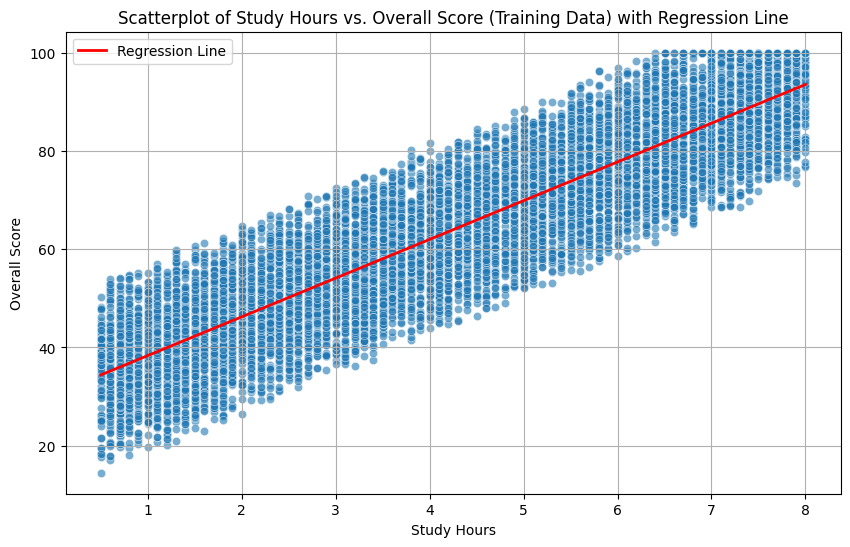

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a DataFrame for plotting training data
training_plot_df = pd.DataFrame({
    'study_hours': X_train_reg.flatten(),
    'overall_score': y_train_reg
})

# Make predictions for the regression line (using the training data range)
x_line = np.linspace(training_plot_df['study_hours'].min(), training_plot_df['study_hours'].max(), 100)
y_line = model_study_hours.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='overall_score', data=training_plot_df, alpha=0.6)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.title('Scatterplot of Study Hours vs. Overall Score (Training Data) with Regression Line')
plt.xlabel('Study Hours')
plt.ylabel('Overall Score')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
import numpy as np

# Calculate RMSE for training data
rmse_train_study_hours = np.sqrt(mse_train_study_hours)

# Calculate RMSE for test data
rmse_test_study_hours = np.sqrt(mse_test_study_hours)

print(f"Root Mean Squared Error (RMSE) on Training Data: {rmse_train_study_hours:.2f}")
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse_test_study_hours:.2f}")


Root Mean Squared Error (RMSE) on Training Data: 8.03
Root Mean Squared Error (RMSE) on Test Data: 8.08


###attendance_percentage versus overall_score

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd # Ensure pandas is imported for DataFrame operations

# Reshape the explanatory variable for sklearn's LinearRegression from training data
X_train_reg_att = X_train['attendance_percentage'].values.reshape(-1, 1)
y_train_reg_att = y_train.values

# Create and fit the model on the training data
model_attendance_percentage = LinearRegression()
model_attendance_percentage.fit(X_train_reg_att, y_train_reg_att)

# Get the intercept and coefficient
intercept_attendance_percentage = model_attendance_percentage.intercept_
coefficient_attendance_percentage = model_attendance_percentage.coef_[0]

print(f"Regression Line on Training Data: overall_score = {coefficient_attendance_percentage:.2f} * attendance_percentage + {intercept_attendance_percentage:.2f}")

# Make predictions on the training set
y_train_pred_attendance_percentage = model_attendance_percentage.predict(X_train_reg_att)

# Calculate R-squared and MSE for the training set
r2_train_attendance_percentage = r2_score(y_train_reg_att, y_train_pred_attendance_percentage)
mse_train_attendance_percentage = mean_squared_error(y_train_reg_att, y_train_pred_attendance_percentage)

print(f"  R-squared on Training Data: {r2_train_attendance_percentage:.2f}")
print(f"  Mean Squared Error (MSE) on Training Data: {mse_train_attendance_percentage:.2f}")

# Prepare the 'attendance_percentage' column from X_test for prediction
X_test_attendance_percentage_reg = X_test['attendance_percentage'].values.reshape(-1, 1)

# Make predictions on the test set
y_test_pred_attendance_percentage = model_attendance_percentage.predict(X_test_attendance_percentage_reg)

# Calculate R-squared and MSE for the test set
r2_test_attendance_percentage = r2_score(y_test, y_test_pred_attendance_percentage)
mse_test_attendance_percentage = mean_squared_error(y_test, y_test_pred_attendance_percentage)

print(f"\nMultiple Linear Regression Model (Test Data):")
print(f"  R-squared on Test Data: {r2_test_attendance_percentage:.2f}")
print(f"  Mean Squared Error (MSE) on Test Data: {mse_test_attendance_percentage:.2f}")

Regression Line on Training Data: overall_score = 0.37 * attendance_percentage + 35.93
  R-squared on Training Data: 0.08
  Mean Squared Error (MSE) on Training Data: 328.87

Multiple Linear Regression Model (Test Data):
  R-squared on Test Data: 0.09
  Mean Squared Error (MSE) on Test Data: 335.38


###multiple linear regression with 2 quantitative explanatory variables

In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define the explanatory variables for multiple linear regression
features = ['study_hours', 'attendance_percentage']

# Create the multiple linear regression model
model_multi = Pipeline([('scaler', StandardScaler()),('clf',LinearRegression())])

# Fit the model to the training data
model_multi.fit(X_train[features], y_train)

# Make predictions on the training set
y_train_pred_multi = model_multi.predict(X_train[features])

# Calculate R-squared and MSE for the training set
r2_train_multi = r2_score(y_train, y_train_pred_multi)
mse_train_multi = mean_squared_error(y_train, y_train_pred_multi)

print(f"Multiple Linear Regression Model (Training Data):")
print(f"  R-squared: {r2_train_multi:.2f}")
print(f"  Mean Squared Error (MSE): {mse_train_multi:.2f}")

# Make predictions on the test set
y_test_pred_multi = model_multi.predict(X_test[features])

# Calculate R-squared and MSE for the test set
r2_test_multi = r2_score(y_test, y_test_pred_multi)
mse_test_multi = mean_squared_error(y_test, y_test_pred_multi)

print(f"\nMultiple Linear Regression Model (Test Data):")
print(f"  R-squared: {r2_test_multi:.2f}")
print(f"  Mean Squared Error (MSE): {mse_test_multi:.2f}")

Multiple Linear Regression Model (Training Data):
  R-squared: 0.91
  Mean Squared Error (MSE): 32.72

Multiple Linear Regression Model (Test Data):
  R-squared: 0.91
  Mean Squared Error (MSE): 33.18


In [59]:
print(f"Coefficients: {model_multi.named_steps['clf'].coef_}")
print(f"Intercept: {model_multi.named_steps['clf'].intercept_}")
print(f"\nMultiple Linear Regression Equation: overall_score = ({model_multi.named_steps['clf'].coef_[0]:.2f} * study_hours) + ({model_multi.named_steps['clf'].coef_[1]:.2f} * attendance_percentage) + {model_multi.named_steps['clf'].intercept_:.2f}")

Coefficients: [17.21070629  5.63331895]
Intercept: 64.05970833333333

Multiple Linear Regression Equation: overall_score = (17.21 * study_hours) + (5.63 * attendance_percentage) + 64.06


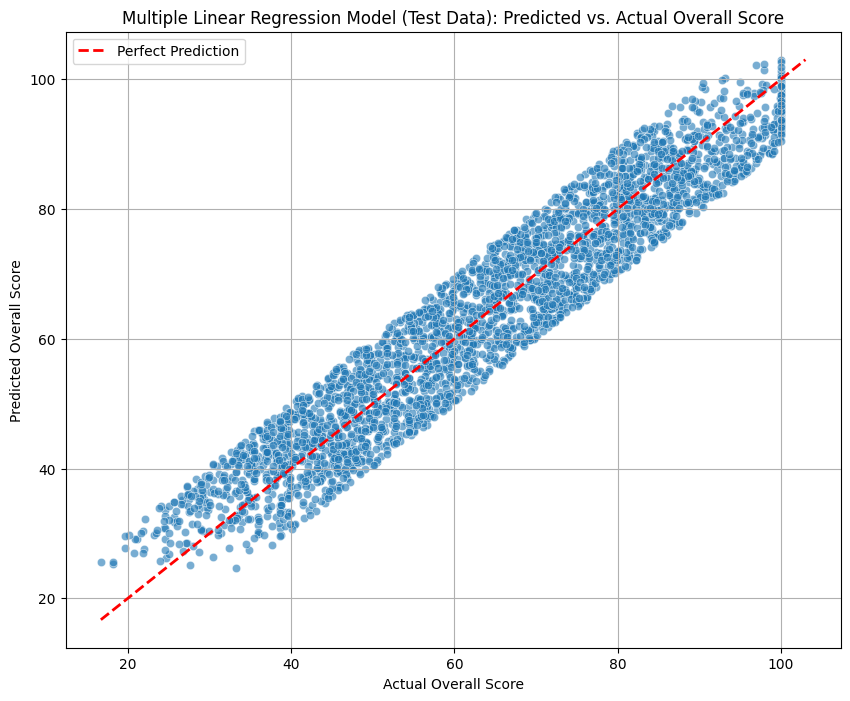

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of predicted vs actual values for the test set
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_test_pred_multi, alpha=0.6)

# Add a line for perfect prediction (where predicted == actual)
min_val = min(y_test.min(), y_test_pred_multi.min())
max_val = max(y_test.max(), y_test_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Multiple Linear Regression Model (Test Data): Predicted vs. Actual Overall Score')
plt.xlabel('Actual Overall Score')
plt.ylabel('Predicted Overall Score')
plt.legend()
plt.grid(True)
plt.show()

In [61]:
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

# Define the coefficients and intercept from the specified equation (these are for SCALED features)
coefficient_study_hours = 17.21
coefficient_attendance_percentage = 5.63
intercept = 64.06

# Example raw input values for study_hours and attendance_percentage
example_study_hours_raw = 5.5  # You can change this value
example_attendance_percentage_raw = 85.0 # You can change this value

# Retrieve the scaler used in the model_multi pipeline
# model_multi.named_steps['scaler'] is the StandardScaler object
scaler = model_multi.named_steps['scaler']

# Define feature names as expected by the scaler (from X_train[features])
feature_names_for_scaler = ['study_hours', 'attendance_percentage']

# Create a DataFrame from the raw input values with the correct feature names
raw_inputs_df = pd.DataFrame([[example_study_hours_raw, example_attendance_percentage_raw]],
                             columns=feature_names_for_scaler)

# Scale the example raw values using the retrieved scaler
scaled_inputs = scaler.transform(raw_inputs_df)

# Extract the scaled study_hours and attendance_percentage
example_study_hours_scaled = scaled_inputs[0, 0]
example_attendance_percentage_scaled = scaled_inputs[0, 1]

# Calculate the overall_score using the direct equation with SCALED values
predicted_overall_score = (coefficient_study_hours * example_study_hours_scaled) + \
                          (coefficient_attendance_percentage * example_attendance_percentage_scaled) + \
                          intercept

print(f"For raw study_hours = {example_study_hours_raw} and raw attendance_percentage = {example_attendance_percentage_raw}:")
print(f"  Scaled study_hours = {example_study_hours_scaled:.2f}")
print(f"  Scaled attendance_percentage = {example_attendance_percentage_scaled:.2f}")
print(f"Predicted overall_score = {predicted_overall_score:.2f}")

For raw study_hours = 5.5 and raw attendance_percentage = 85.0:
  Scaled study_hours = 0.57
  Scaled attendance_percentage = 0.69
Predicted overall_score = 77.75


###multiple linear regression with quantative and catagorical explanatory variables

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define the quantitative explanatory variables
quantitative_features = ['study_hours', 'attendance_percentage']

# Define the categorical explanatory variables
categorical_features = ['parent_education', 'school_type']

# Create dummy variables for categorical features
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Prepare the list of all features for the model
# This includes the original quantitative features and the new dummy variables
all_model_features = quantitative_features + [col for col in data_encoded.columns if col.startswith(tuple(categorical_features))]

X_new = data_encoded[all_model_features]
y_new = data_encoded['overall_score']

# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, train_size=0.8, random_state=42)

# Create a preprocessor to scale quantitative features and pass through categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), quantitative_features), # Apply StandardScaler to quantitative features
        ('cat', 'passthrough', [col for col in all_model_features if col not in quantitative_features]) # Pass through categorical dummy features
    ])

# Create the multiple linear regression model pipeline
model_multi_new = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', LinearRegression())])

# Fit the model to the training data
model_multi_new.fit(X_train_new, y_train_new)

# Make predictions on the training set
y_train_pred_multi_new = model_multi_new.predict(X_train_new)

# Calculate R-squared and MSE for the training set
r2_train_multi_new = r2_score(y_train_new, y_train_pred_multi_new)
mse_train_multi_new = mean_squared_error(y_train_new, y_train_pred_multi_new)

print(f"Multiple Linear Regression Model (Training Data - with more features and scaling):")
print(f"  R-squared: {r2_train_multi_new:.2f}")
print(f"  Mean Squared Error (MSE): {mse_train_multi_new:.2f}")

# Make predictions on the test set
y_test_pred_multi_new = model_multi_new.predict(X_test_new)

# Calculate R-squared and MSE for the test set
r2_test_multi_new = r2_score(y_test_new, y_test_pred_multi_new)
mse_test_multi_new = mean_squared_error(y_test_new, y_test_pred_multi_new)

print(f"\nMultiple Linear Regression Model (Test Data - with more features and scaling):")
print(f"  R-squared: {r2_test_multi_new:.2f}")
print(f"  Mean Squared Error (MSE): {mse_test_multi_new:.2f}")

# Get coefficients and intercept from the regressor step in the pipeline
coefs = model_multi_new.named_steps['regressor'].coef_
intercept = model_multi_new.named_steps['regressor'].intercept_

# Get feature names after preprocessing
# This correctly maps coefficients back to their original (or transformed) feature names
transformed_feature_names = model_multi_new.named_steps['preprocessor'].get_feature_names_out()

print(f"\nCoefficients: {coefs}")
print(f"Intercept: {intercept:.2f}")

# Print the full equation
equation_terms = [f"({c:.2f} * {name})" for c, name in zip(coefs, transformed_feature_names)]
equation = f"overall_score = {' + '.join(equation_terms)} + {intercept:.2f}"
print(f"\nMultiple Linear Regression Equation (with scaled features):\n{equation}")


Multiple Linear Regression Model (Training Data - with more features and scaling):
  R-squared: 0.91
  Mean Squared Error (MSE): 32.70

Multiple Linear Regression Model (Test Data - with more features and scaling):
  R-squared: 0.91
  Mean Squared Error (MSE): 33.23

Coefficients: [ 1.72111030e+01  5.63367566e+00  1.26461046e-01 -1.39291848e-01
 -8.91564212e-03 -1.20601655e-01  1.45451147e-01  2.03028802e-01]
Intercept: 63.96

Multiple Linear Regression Equation (with scaled features):
overall_score = (17.21 * num__study_hours) + (5.63 * num__attendance_percentage) + (0.13 * cat__parent_education_graduate) + (-0.14 * cat__parent_education_high school) + (-0.01 * cat__parent_education_no formal) + (-0.12 * cat__parent_education_phd) + (0.15 * cat__parent_education_post graduate) + (0.20 * cat__school_type_public) + 63.96


##Logistic Regression - Predict Whether or not a Student will get an A

In [63]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define 'A' grade as overall_score >= 90
data['is_a_grade'] = (data['overall_score'] >= 90).astype(int)

# Identify all potential explanatory variables excluding identifiers and target variables
# 'student_id' is an identifier, 'overall_score' is the basis for 'is_a_grade'
# and 'is_a_grade' is the target itself.
exclude_cols = ['student_id', 'overall_score', 'is_a_grade']
all_possible_features = [col for col in data.columns if col not in exclude_cols]

# Create dummy variables for all categorical features within this set
data_for_classification = data.copy()
data_encoded_for_class = pd.get_dummies(data_for_classification, columns=[col for col in all_possible_features if data_for_classification[col].dtype == 'object'], drop_first=True)

# Re-define the list of all features after encoding (including new dummy columns)
# Filter out any original categorical columns that have been replaced by dummies
all_features_for_class = [col for col in data_encoded_for_class.columns if col not in exclude_cols and col not in [c for c in all_possible_features if data_for_classification[c].dtype == 'object']]
all_features_for_class.extend([col for col in data_encoded_for_class.columns if any(s in col for s in [c for c in all_possible_features if data_for_classification[c].dtype == 'object'])])

X_class = data_encoded_for_class[all_features_for_class]
y_class = data_encoded_for_class['is_a_grade']

# Split the data into training and testing sets (80% for training)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, train_size=0.8, random_state=42)

print(f'Shape of X_train_class: {X_train_class.shape}')
print(f'Shape of X_test_class: {X_test_class.shape}')
print(f'Shape of y_train_class: {y_train_class.shape}')
print(f'Shape of y_test_class: {y_test_class.shape}')

print(f"\nNumber of 'A' grades in training set: {y_train_class.sum()} ({y_train_class.mean():.2%})")
print(f"Number of 'A' grades in test set: {y_test_class.sum()} ({y_test_class.mean():.2%})")

Shape of X_train_class: (12000, 52)
Shape of X_test_class: (3000, 52)
Shape of y_train_class: (12000,)
Shape of y_test_class: (3000,)

Number of 'A' grades in training set: 1132 (9.43%)
Number of 'A' grades in test set: 274 (9.13%)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define explanatory variable for this specific model
X_train_study_hours_class = X_train_class[['study_hours']]
X_test_study_hours_class = X_test_class[['study_hours']]

# Create and train the Logistic Regression model
model_a_grade_study_hours = LogisticRegression(random_state=42)
model_a_grade_study_hours.fit(X_train_study_hours_class, y_train_class)

# Make predictions on the training set
y_train_pred_a_grade_study_hours = model_a_grade_study_hours.predict(X_train_study_hours_class)

# Evaluate training set performance
print("--- Training Set Performance (A Grade vs Study Hours) ---")
print(f"Accuracy: {accuracy_score(y_train_class, y_train_pred_a_grade_study_hours):.2f}")
print("Classification Report:")
print(classification_report(y_train_class, y_train_pred_a_grade_study_hours))
print("Confusion Matrix:")
print(confusion_matrix(y_train_class, y_train_pred_a_grade_study_hours))

# Make predictions on the test set
y_test_pred_a_grade_study_hours = model_a_grade_study_hours.predict(X_test_study_hours_class)

# Evaluate test set performance
print("\n--- Test Set Performance (A Grade vs Study Hours) ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_test_pred_a_grade_study_hours):.2f}")
print("Classification Report:")
print(classification_report(y_test_class, y_test_pred_a_grade_study_hours))
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_test_pred_a_grade_study_hours))

--- Training Set Performance (A Grade vs Study Hours) ---
Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     10868
           1       0.60      0.48      0.53      1132

    accuracy                           0.92     12000
   macro avg       0.77      0.72      0.74     12000
weighted avg       0.91      0.92      0.92     12000

Confusion Matrix:
[[10499   369]
 [  587   545]]

--- Test Set Performance (A Grade vs Study Hours) ---
Accuracy: 0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      2726
           1       0.55      0.41      0.47       274

    accuracy                           0.92      3000
   macro avg       0.75      0.69      0.71      3000
weighted avg       0.91      0.92      0.91      3000

Confusion Matrix:
[[2634   92]
 [ 162  112]]


###explanatory variable is internet_accss and parent_education

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Define the explanatory variables for this specific model
# Get all dummy columns related to 'parent_education' and 'internet_access_yes'
parent_education_features = [col for col in X_train_class.columns if col.startswith('parent_education_')]
internet_access_feature = ['internet_access_yes']

features_for_a_grade_model_2 = parent_education_features + internet_access_feature

X_train_a_grade_model_2 = X_train_class[features_for_a_grade_model_2]
X_test_a_grade_model_2 = X_test_class[features_for_a_grade_model_2]

# Create and train the Logistic Regression model
model_a_grade_model_2 = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' handles small datasets and L1/L2 regularization
model_a_grade_model_2.fit(X_train_a_grade_model_2, y_train_class)

# Make predictions on the training set
y_train_pred_a_grade_model_2 = model_a_grade_model_2.predict(X_train_a_grade_model_2)

# Evaluate training set performance
print("--- Training Set Performance (A Grade vs Parent Education & Internet Access) ---")
print(f"Accuracy: {accuracy_score(y_train_class, y_train_pred_a_grade_model_2):.2f}")
print("Classification Report:")
print(classification_report(y_train_class, y_train_pred_a_grade_model_2))
print("Confusion Matrix:")
print(confusion_matrix(y_train_class, y_train_pred_a_grade_model_2))

# Make predictions on the test set
y_test_pred_a_grade_model_2 = model_a_grade_model_2.predict(X_test_a_grade_model_2)

# Evaluate test set performance
print("\n--- Test Set Performance (A Grade vs Parent Education & Internet Access) ---")
print(f"Accuracy: {accuracy_score(y_test_class, y_test_pred_a_grade_model_2):.2f}")
print("Classification Report:")
print(classification_report(y_test_class, y_test_pred_a_grade_model_2))
print("Confusion Matrix:")
print(confusion_matrix(y_test_class, y_test_pred_a_grade_model_2))

--- Training Set Performance (A Grade vs Parent Education & Internet Access) ---
Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     10868
           1       0.00      0.00      0.00      1132

    accuracy                           0.91     12000
   macro avg       0.45      0.50      0.48     12000
weighted avg       0.82      0.91      0.86     12000

Confusion Matrix:
[[10868     0]
 [ 1132     0]]

--- Test Set Performance (A Grade vs Parent Education & Internet Access) ---
Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95      2726
           1       0.00      0.00      0.00       274

    accuracy                           0.91      3000
   macro avg       0.45      0.50      0.48      3000
weighted avg       0.83      0.91      0.87      3000

Confusion Matrix:
[[2726    0]
 [ 274    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### Confusion Matrix Layout Reminder

For a binary classification, the confusion matrix is typically structured as follows, where rows represent **Actual** classes and columns represent **Predicted** classes:

| | **Predicted Negative (Class 0)** | **Predicted Positive (Class 1)** |
| :----------------- | :----------------------------------- | :---------------------------------- |
| **Actual Negative (Class 0)** | True Negative (TN) | False Positive (FP) |
| **Actual Positive (Class 1)** | False Negative (FN) | True Positive (TP) |

Now, let's look at your model results with these labels.

In [66]:
from google.colab import drive
drive.flush_and_unmount()